# Módulo 07 - Tarefa 02

#### 1) Carregue a base e garanta que a base está como deveria.

Considere a base que você ajustou na lição passada. Carregue-a. Caso ainda haja alguma pendência, ajuste - lembre-se de que o scikitlearn não recebe variáveis em formato string, somente numéricas, e não aceita '*missings*'. 

- Separe 70% da base para treinamento e 30% para validação. Cada uma dessas partes terá dois objetos, um armazenando a variável resposta ```mau```e outro armazenando as variáveis explicativas (lembrando: sem variáveis string, já com as dummies).

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_final = pd.read_csv('dataframe_preparado.csv')

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16650 entries, 0 to 16649
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   qtd_filhos                              16650 non-null  int64  
 1   idade                                   16650 non-null  float64
 2   tempo_emprego                           16650 non-null  float64
 3   possui_celular                          16650 non-null  int64  
 4   possui_fone_comercial                   16650 non-null  int64  
 5   possui_fone                             16650 non-null  int64  
 6   possui_email                            16650 non-null  int64  
 7   qt_pessoas_residencia                   16650 non-null  float64
 8   mau                                     16650 non-null  int64  
 9   sexo_M                                  16650 non-null  int64  
 10  posse_de_veiculo_Y                      16650 non-null  in

In [3]:
y = df_final['mau']

X = df_final.drop('mau', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

print(f"X_train (treino): {X_train.shape}")
print(f"X_test (validação): {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train (treino): (11655, 28)
X_test (validação): (4995, 28)
y_train: (11655,)
y_test: (4995,)


In [6]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=100)

clf.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [7]:
from sklearn.metrics import accuracy_score

predict_treino = clf.predict(X_train)
predict_teste = clf.predict(X_test)

acc_treino = accuracy_score(y_train, predict_treino)
acc_teste = accuracy_score(y_test, predict_teste)

print(f"Acurácia no Treino: {acc_treino*100:.2f}%")
print(f"Acurácia no Teste: {acc_teste*100:.2f}%")

Acurácia no Treino: 99.11%
Acurácia no Teste: 96.84%


#### 2) Vamos para o modelo:

1. Defina um objeto com a função da árvore de decisão vista em aula.
2. Treine o modelo com os dados que você separou para treinamento.
3. Visualize a árvore. Talvez você queira aumentar um pouco a figura.
4. Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.
5. Calcule a acurácia na base de treinamento

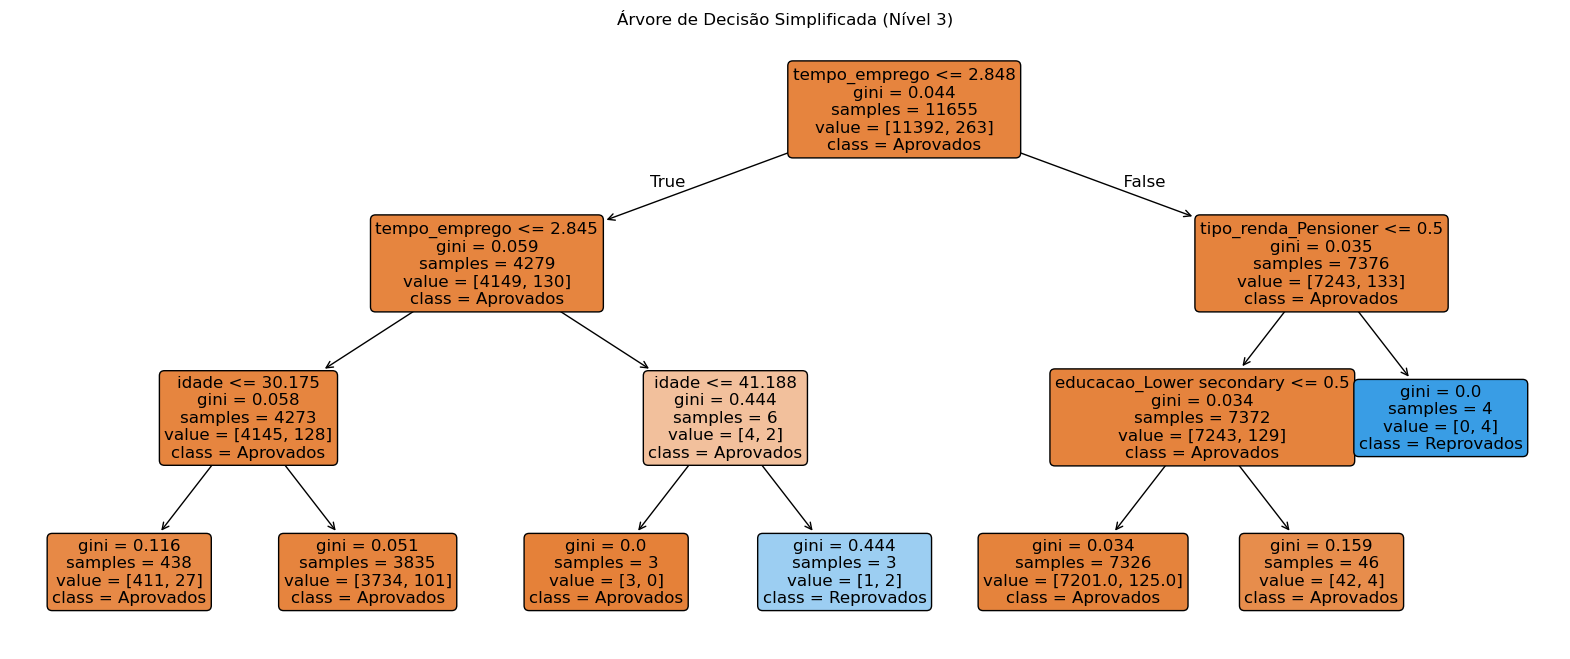

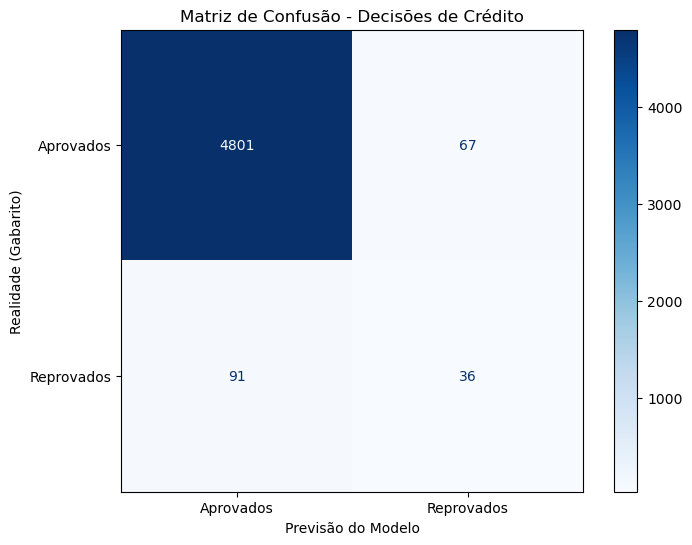

Acurácia na base de treinamento: 99.11%


In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

clf_simples = DecisionTreeClassifier(max_depth=3, random_state=100)
clf_simples.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(clf_simples, 
          feature_names=list(X.columns), 
          class_names=['Aprovados', 'Reprovados'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Árvore de Decisão Simplificada (Nível 3)")
plt.show()


predict_teste = clf.predict(X_test)

cm = confusion_matrix(y_test, predict_teste)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovados', 'Reprovados'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Matriz de Confusão - Decisões de Crédito")
plt.xlabel("Previsão do Modelo")
plt.ylabel("Realidade (Gabarito)")
plt.show()

predict_treino = clf.predict(X_train)
acc_treino = accuracy_score(y_train, predict_treino)

print(f"Acurácia na base de treinamento: {acc_treino * 100:.2f}%")

#### 3) Vamos avaliar o modelo na base de testes

1. Classifique a base de teste de acordo com a árvore que você treinou no item 2.
2. Produza a visualização da matriz de confusão para a base de teste.
3. Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.
4. Treine uma nova árvore com número mínimo de observações por folha de 5 e máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?
5. Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

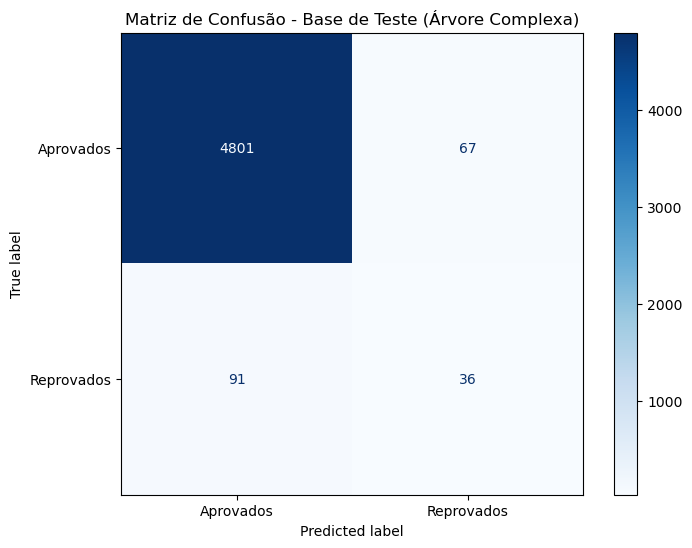

Acurácia Treinamento: 99.11%
Acurácia Teste:       96.84%


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

predict_teste = clf.predict(X_test)

plt.figure(figsize=(8, 6))
cm_teste = confusion_matrix(y_test, predict_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_teste, display_labels=['Aprovados', 'Reprovados'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Matriz de Confusão - Base de Teste (Árvore Complexa)")
plt.show()

acc_teste = accuracy_score(y_test, predict_teste)
print(f"Acurácia Treinamento: {acc_treino * 100:.2f}%")
print(f"Acurácia Teste:       {acc_teste * 100:.2f}%")

Proporção de proponentes classificados como 'Maus': 0.62%


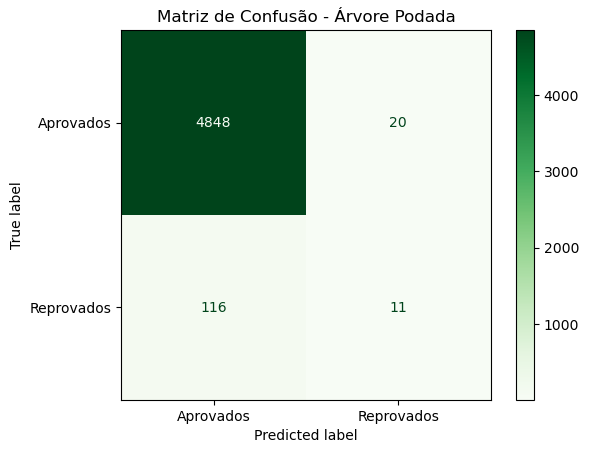

In [11]:
clf_podada = DecisionTreeClassifier(max_depth=10, 
                                    min_samples_leaf=5, 
                                    random_state=123)
clf_podada.fit(X_train, y_train)

predict_podada = clf_podada.predict(X_test)
cm_podada = confusion_matrix(y_test, predict_podada)

proporcao_maus = (predict_podada.sum() / len(predict_podada)) * 100

print(f"Proporção de proponentes classificados como 'Maus': {proporcao_maus:.2f}%")

disp_podada = ConfusionMatrixDisplay(confusion_matrix=cm_podada, display_labels=['Aprovados', 'Reprovados'])
disp_podada.plot(cmap='Greens', values_format='d')
plt.title("Matriz de Confusão - Árvore Podada")
plt.show()

In [12]:
pred_all_good = [0] * len(y_test)
acc_baseline = accuracy_score(y_test, pred_all_good)

print(f"Acurácia se todos fossem 'Bons': {acc_baseline * 100:.2f}%")

Acurácia se todos fossem 'Bons': 97.46%
